# TinyArabicLM — Arabic Language Model from Scratch

Training a small Transformer on Arabic Wikipedia data.
Architecture: [Attention Is All You Need](https://arxiv.org/abs/1706.03762)

| Feature | Details |
|---|---|
| Dataset | Arabic Wikipedia (20231101.ar) |
| Tokenizer | AraBERT (aubmindlab/bert-base-arabertv2) |
| Model size | 30M parameters |
| Hardware | Google Colab T4 (Free) |

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BELYAGOUBIABDELILAH/llm-from-scratch/blob/main/02_arabic_lm.ipynb)

In [1]:
!pip install torch datasets transformers tqdm matplotlib -q

import os
if not os.path.exists('llm-from-scratch'):
    !git clone https://github.com/BELYAGOUBIABDELILAH/llm-from-scratch
%cd llm-from-scratch
!git pull origin main

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/llm_project/arabic'
os.makedirs(f'{DRIVE_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{DRIVE_DIR}/images',      exist_ok=True)
print(f'Drive mounted — outputs will be saved to: {DRIVE_DIR}')

import torch
from src.models.transformer import Transformer
from config.config import MODEL_CONFIGS, TRAIN_CONFIG

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Cloning into 'llm-from-scratch'...
remote: Enumerating objects: 171, done.
remote: Counting objects: 100% (171/171), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 171 (delta 50), reused 158 (delta 40), pack-reused 0 (from 0)
Receiving objects: 100% (171/171), 5.94 MiB | 33.82 MiB/s, done.
Resolving deltas: 100% (50/50), done.
/content/llm-from-scratch
From https://github.com/BELYAGOUBIABDELILAH/llm-from-scratch
 * branch            main       -> FETCH_HEAD
Already up to date.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted — outputs will be saved to: /content/drive/MyDrive/llm_project/arabic
Device: cuda


In [2]:
from data_loader.arabic_loader import load_arabic_data

tokenized_arabic, arabic_tokenizer = load_arabic_data(
    max_samples=20000,  # Keep small for Colab
    max_length=512
)

vocab_size = arabic_tokenizer.vocab_size
print(f'Arabic vocab size: {vocab_size}')
print(f'Sample count: {len(tokenized_arabic)}')

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikimedia/wikipedia' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikimedia/wikipedia' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading Arabic Wikipedia dataset...


README.md:   0%|          | 0.00/131k [00:00<?, ?B/s]

20231101.ar/train-00000-of-00007.parquet: reconstructing file:   0%|          |  0.00B /  408MB            

20231101.ar/train-00000-of-00007.parquet: downloading bytes:           |  0.00B            

...

tokenizer.json:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizing Arabic text...


Tokenizing:   0%|          | 0/20000 [00:00<?, ? examples/s]

Arabic dataset ready: 20000 samples
Arabic vocab size: 64000
Sample count: 20000


In [3]:
# Use 30M config but with Arabic vocab size
arabic_config = {**MODEL_CONFIGS['30M']}
arabic_config['vocab_size'] = vocab_size

model = Transformer(**arabic_config).to(device)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Arabic LM: {params/1e6:.1f}M parameters')

Arabic LM: 91.1M parameters


Training Arabic LM: 100%|██████████| 1000/1000 [10:27<00:00,  1.59it/s]


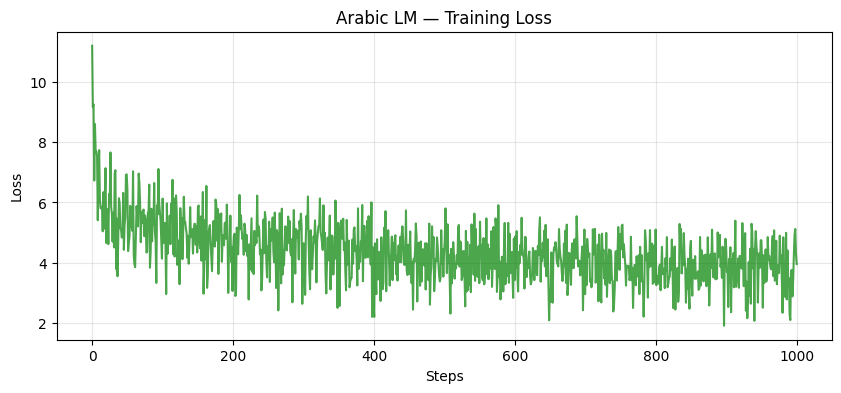

In [4]:
import matplotlib.pyplot as plt
from tqdm import tqdm

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
loader = torch.utils.data.DataLoader(tokenized_arabic, batch_size=8, shuffle=True)

losses = []
model.train()

for step, batch in enumerate(tqdm(loader, total=1000, desc='Training Arabic LM')):
    if step >= 1000:
        break

    input_ids = batch['input_ids'].to(device)
    x = input_ids[:, :-1]
    y = input_ids[:, 1:]

    optimizer.zero_grad()
    logits = model(x)
    loss = torch.nn.functional.cross_entropy(
        logits.reshape(-1, vocab_size),
        y.reshape(-1).long()
    )
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    losses.append(loss.item())

# Plot
plt.figure(figsize=(10, 4))
plt.plot(losses, alpha=0.7, color='green')
plt.title('Arabic LM — Training Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.savefig('arabic_training_loss.png', dpi=150)
plt.show()

In [5]:
import shutil

# Save image
shutil.copy('arabic_training_loss.png', f'{DRIVE_DIR}/images/arabic_training_loss.png')
print(f'Image saved -> {DRIVE_DIR}/images/arabic_training_loss.png')

# Save checkpoint
ckpt_path = f'{DRIVE_DIR}/checkpoints/arabic_lm_30M.pt'
torch.save({
    'model_state_dict': model.state_dict(),
    'config':           arabic_config,
    'vocab_size':       vocab_size,
    'final_loss':       round(losses[-1], 4),
    'total_steps':      len(losses),
    'tokenizer_name':   'aubmindlab/bert-base-arabertv2',
}, ckpt_path)
print(f'Arabic model saved -> {ckpt_path}')

print("""
To resume training later:
  checkpoint = torch.load(ckpt_path)
  model.load_state_dict(checkpoint['model_state_dict'])
  print(f"Resumed from step {checkpoint['total_steps']}")
""")

Image saved -> /content/drive/MyDrive/llm_project/arabic/images/arabic_training_loss.png
Arabic model saved -> /content/drive/MyDrive/llm_project/arabic/checkpoints/arabic_lm_30M.pt

To resume training later:
  checkpoint = torch.load(ckpt_path)
  model.load_state_dict(checkpoint['model_state_dict'])
  print(f"Resumed from step {checkpoint['total_steps']}")



In [6]:
def generate_arabic(model, prompt, tokenizer, max_new_tokens=30):
    model.eval()
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        for _ in range(max_new_tokens):
            input_cond = input_ids[:, -model.context_length:]
            output = model(input_cond)
            logits = output[0] if isinstance(output, tuple) else output
            next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
            input_ids = torch.cat([input_ids, next_token], dim=1)
    return tokenizer.decode(input_ids[0], skip_special_tokens=True)

# Test with Arabic prompts
prompts = ['الذكاء الاصطناعي', 'الجزائر دولة', 'اللغة العربية']
for prompt in prompts:
    print(f'\nPrompt: {prompt}')
    print(f'Generated: {generate_arabic(model, prompt, arabic_tokenizer)}')



Prompt: الذكاء الاصطناعي
Generated: الذكاء الاصطناعي

Prompt: الجزائر دولة
Generated: الجزائر دولة

Prompt: اللغة العربية
Generated: اللغة العربية
